# 5.2 感情分析モデルの実装

## 5.2.1 環境の準備

In [5]:
%pip install 'transformers[ja,torch]<4.41.0'  'datasets<4.0.0' matplotlib japanize-matplotlib

In [6]:
# transformers 4.40.2 と Colab プリインストールの新しい peft が非互換
# (peft が EncoderDecoderCache を要求するが transformers 4.40 には存在しない)
# このノートブックでは peft を使わないのでアンインストールして回避する
%pip uninstall -y peft

In [7]:
from transformers.trainer_utils import set_seed
set_seed(42)

## 5.2.2 データセットの準備

In [8]:
from pprint import pprint
from datasets import load_dataset

# MARC-jaと同様の感情分析のデータセットであるWRIMEを用いて書籍と同様のコードを実行
train_dataset = load_dataset("llm-book/wrime-sentiment", split="train")
valid_dataset = load_dataset("llm-book/wrime-sentiment", split="validation")

# pprintで見やすく表示する
pprint(train_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


{'datetime': '2012/7/31 23:48',
 'label': 1,
 'sentence': 'ぼけっとしてたらこんな時間。チャリあるから食べにでたいのに…',
 'user_id': 1}


In [9]:
pprint(train_dataset.features)

{'datetime': Value(dtype='string', id=None),
 'label': ClassLabel(names=['positive', 'negative'], id=None),
 'sentence': Value(dtype='string', id=None),
 'user_id': Value(dtype='int64', id=None)}


## 5.2.3 トークナイザ
文章をトークンに変換

In [10]:
from transformers import AutoTokenizer

model_name = "cl-tohoku/bert-base-japanese-v3"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(type(tokenizer).__name__)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


BertJapaneseTokenizer


In [11]:
tokenizer.tokenize("これはテストです。")

['これ', 'は', 'テスト', 'です', '。']

In [12]:
encoded_input = tokenizer("これはテストです。")
print(type(encoded_input).__name__)

BatchEncoding


In [13]:
pprint(encoded_input)

{'attention_mask': [1, 1, 1, 1, 1, 1, 1],
 'input_ids': [2, 12538, 465, 14985, 13037, 385, 3],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0]}


In [14]:
# test
exp_encoded_input = tokenizer("これはテストです。コメダのかつパンはとても大きくてお腹はいっぱいだ。")
pprint(exp_encoded_input)

{'attention_mask': [1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1,
                    1],
 'input_ids': [2,
               12538,
               465,
               14985,
               13037,
               385,
               16163,
               536,
               464,
               12763,
               13972,
               465,
               17501,
               13345,
               456,
               428,
               9044,
               465,
               23617,
               450,
               385,
               3],
 'token_type_ids': [0,
              

In [15]:
tokenizer.convert_ids_to_tokens(encoded_input["input_ids"])

['[CLS]', 'これ', 'は', 'テスト', 'です', '。', '[SEP]']

## 5.2.4 データセット統計の可視化

100%|██████████| 20149/20149 [00:04<00:00, 4821.34it/s]


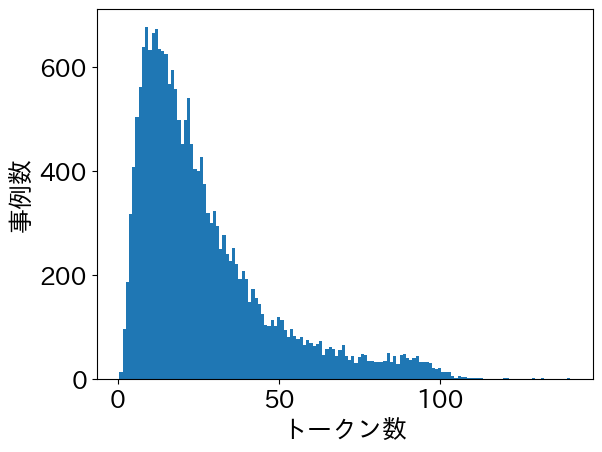

100%|██████████| 1608/1608 [00:00<00:00, 2701.65it/s]


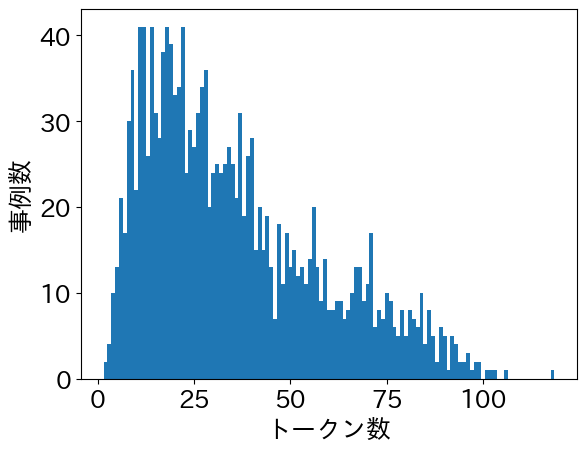

In [16]:
from collections import Counter
import japanize_matplotlib
import matplotlib.pyplot as plt
from datasets import Dataset
from tqdm import tqdm

plt.rcParams["font.size"] = 18  # 文字サイズを大きくする

def visualize_text_length(dataset: Dataset):
    """データセット中のテキストのトークン数の分布をグラフとして描画"""
    # データセット中のテキストの長さを数える
    length_counter = Counter()
    for data in tqdm(dataset):
        length = len(tokenizer.tokenize(data["sentence"]))
        length_counter[length] += 1
    # length_counterの値から棒グラフを描画する
    plt.bar(length_counter.keys(), length_counter.values(), width=1.0)
    plt.xlabel("トークン数")
    plt.ylabel("事例数")
    plt.show()

visualize_text_length(train_dataset)
visualize_text_length(valid_dataset)

In [17]:
for data in valid_dataset:
    if len(tokenizer.tokenize(data["sentence"])) < 10:
        pprint(data)

{'datetime': '2020/5/15 17:35',
 'label': 1,
 'sentence': 'よくわからない連携。',
 'user_id': 26}
{'datetime': '2020/5/15 17:47',
 'label': 1,
 'sentence': 'この3年が無駄になった。',
 'user_id': 26}
{'datetime': '2020/5/15 17:48',
 'label': 1,
 'sentence': '空気を読んでなくて。',
 'user_id': 26}
{'datetime': '2020/5/15 17:52',
 'label': 1,
 'sentence': 'っていうか、英語の聞きすぎ',
 'user_id': 26}
{'datetime': '2020/5/18 16:31',
 'label': 0,
 'sentence': '明日は楽しみかも。',
 'user_id': 26}
{'datetime': '2020/5/19 11:55',
 'label': 1,
 'sentence': '今日は誤字だらけ。',
 'user_id': 26}
{'datetime': '2020/5/21 8:29',
 'label': 0,
 'sentence': 'SUNがいいなと思った。',
 'user_id': 26}
{'datetime': '2020/5/5 6:50',
 'label': 0,
 'sentence': 'わさび醤油、結構合う。',
 'user_id': 28}
{'datetime': '2020/5/6 6:13',
 'label': 1,
 'sentence': '朝から本当に腹立たしい。',
 'user_id': 28}
{'datetime': '2020/5/6 6:27',
 'label': 1,
 'sentence': 'しかも本人は反省の色なし',
 'user_id': 28}
{'datetime': '2020/5/6 8:18', 'label': 1, 'sentence': '書けない', 'user_id': 28}
{'datetime': '2020/3/2 19:32',
 'label':

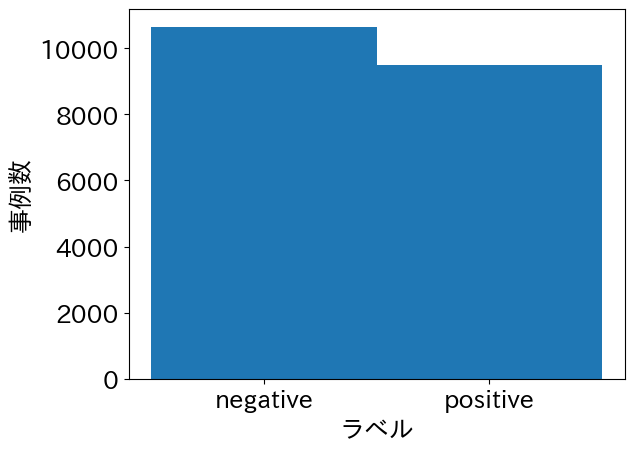

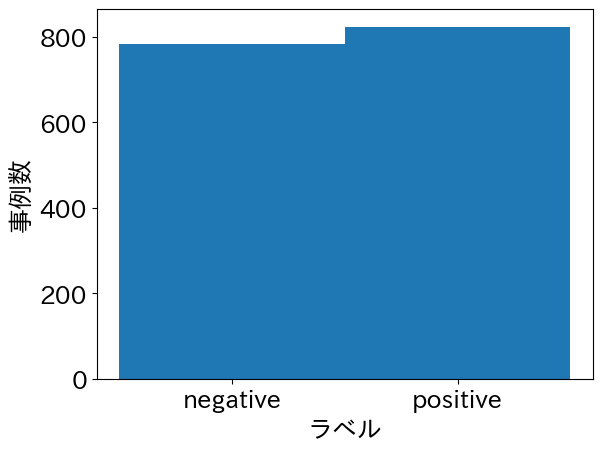

In [18]:
def visualize_labels(dataset: Dataset):
    """データセット中のラベル分布をグラフとして描画"""
    label_counter = Counter()
    for data in dataset:
        label_id = data["label"]
        label_name = dataset.features["label"].names[label_id]
        label_counter[label_name] += 1

    plt.bar(label_counter.keys(), label_counter.values(), width=1.0)
    plt.xlabel("ラベル")
    plt.ylabel("事例数")
    plt.show()

visualize_labels(train_dataset)
visualize_labels(valid_dataset)


## 5.2.5 データセットの前処理
データセット内のテキストを、トークンを表すIDの系列に変換する

In [19]:
from transformers import BatchEncoding

def preprocess_text_classification(
    example: dict[str, str | int]
) -> BatchEncoding:
    """文書分類の事例のテキストをトークナイズし、IDに変換"""
    encoded_example = tokenizer(example["sentence"], max_length=512)
    # モデルの入力引数である"labels"をキーとして格納する
    encoded_example["labels"] = example["label"]
    return encoded_example

In [20]:
encoded_train_dataset = train_dataset.map(
    preprocess_text_classification,
    remove_columns=train_dataset.column_names,
)
encoded_valid_dataset = valid_dataset.map(
    preprocess_text_classification,
    remove_columns=valid_dataset.column_names,
)


Parameter 'function'=<function preprocess_text_classification at 0x7d60ddcb5440> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/20149 [00:00<?, ? examples/s]

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Map:   0%|          | 0/1608 [00:00<?, ? examples/s]

In [21]:
print(encoded_train_dataset[0])
print(train_dataset[0])

{'input_ids': [2, 478, 7139, 15269, 441, 456, 13123, 21311, 12671, 385, 12651, 7065, 12485, 12488, 13781, 461, 457, 13030, 464, 461, 29, 29, 29, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 1}
{'sentence': 'ぼけっとしてたらこんな時間。チャリあるから食べにでたいのに…', 'label': 1, 'user_id': 1, 'datetime': '2012/7/31 23:48'}


## 5.2.6 ミニバッチ構築

In [22]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [23]:
batch_inputs = data_collator(encoded_train_dataset[0:4])
pprint({name: tensor.size() for name, tensor in batch_inputs.items()})

{'attention_mask': torch.Size([4, 36]),
 'input_ids': torch.Size([4, 36]),
 'labels': torch.Size([4]),
 'token_type_ids': torch.Size([4, 36])}


## 5.2.7 モデルの準備

In [24]:
from transformers import AutoModelForSequenceClassification

class_label = train_dataset.features["label"]
label2id = {label: id for id, label in enumerate(class_label.names)}
id2label = {id: label for id ,label in enumerate(class_label.names)}
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=class_label.num_classes,
    label2id=label2id,
    id2label=id2label
)
print(type(model).__name__)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-v3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification


In [25]:
print(class_label)

ClassLabel(names=['positive', 'negative'], id=None)


In [26]:
print(model.forward(
    **data_collator(encoded_train_dataset[0:4]), 
    output_hidden_states=True, 
    output_attentions=True
))

SequenceClassifierOutput(loss=tensor(0.8075, grad_fn=<NllLossBackward0>), logits=tensor([[ 0.2869, -0.2644],
        [ 0.1715,  0.0095],
        [ 0.0040,  0.1524],
        [ 0.2233, -0.2968]], grad_fn=<AddmmBackward0>), hidden_states=(tensor([[[-1.6377e-02,  2.9903e-02, -2.8065e-02,  ...,  4.7373e-02,
          -7.3572e-02, -1.3696e-02],
         [-1.1281e+00,  3.2937e-01, -9.7033e-01,  ...,  1.1930e+00,
           4.9878e-01, -5.2145e-01],
         [-6.4123e-01,  1.2080e-01,  5.3409e-03,  ...,  2.0188e-01,
           6.0517e-01, -1.0361e+00],
         ...,
         [-5.9443e-01, -9.8357e-01,  6.2720e-01,  ..., -7.4965e-01,
          -3.0809e-01,  6.6137e-01],
         [-3.5001e-01, -8.7359e-01,  7.4840e-01,  ..., -6.2604e-01,
          -5.0030e-01,  5.6903e-01],
         [-1.7362e-01, -8.9047e-01,  7.8849e-01,  ..., -2.9224e-01,
          -6.1673e-01,  6.3405e-01]],

        [[-1.6377e-02,  2.9903e-02, -2.8065e-02,  ...,  4.7373e-02,
          -7.3572e-02, -1.3696e-02],
         [-7.

In [27]:
print(encoded_train_dataset[0:4])

{'input_ids': [[2, 478, 7139, 15269, 441, 456, 13123, 21311, 12671, 385, 12651, 7065, 12485, 12488, 13781, 461, 457, 13030, 464, 461, 29, 29, 29, 3], [2, 15028, 464, 2806, 484, 30908, 456, 19730, 385, 2724, 7998, 12505, 6483, 430, 14165, 456, 31265, 7106, 460, 7373, 458, 13513, 7241, 13320, 20831, 7951, 385, 12651, 7065, 14176, 13053, 484, 17941, 12494, 385, 3], [2, 4097, 7228, 384, 4097, 7203, 12494, 385, 3], [2, 19890, 4391, 430, 26297, 456, 431, 16328, 385, 15206, 7228, 460, 29, 29, 29, 3]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1

## 5.2.8 訓練の実行

In [28]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="output_wrime",  # 結果の保存フォルダ
    per_device_train_batch_size=32,  # 訓練時のバッチサイズ
    per_device_eval_batch_size=32,  # 評価時のバッチサイズ
    learning_rate=2e-5,  # 学習率
    lr_scheduler_type="linear",  # 学習率スケジューラの種類
    warmup_ratio=0.1,  # 学習率のウォームアップの長さを指定
    num_train_epochs=3,  # エポック数
    save_strategy="epoch",  # チェックポイントの保存タイミング
    logging_strategy="epoch",  # ロギングのタイミング
    evaluation_strategy="epoch",  # 検証セットによる評価のタイミング
    load_best_model_at_end=True,  # 訓練後に開発セットで最良のモデルをロード
    metric_for_best_model="accuracy",  # 最良のモデルを決定する評価指標
    fp16=True,  # 自動混合精度演算の有効化
    report_to="none",  # 外部ツールへのログを無効化
)

In [29]:
import numpy as np

def compute_accuracy(
    eval_pred: tuple[np.ndarray, np.ndarray]
) -> dict[str, float]:
    """予測ラベルと正解ラベルから成果率を計算"""
    predictions, labels = eval_pred
    # predictionsは各ラベルについてのスコア
    # 最もスコアの高いインデックスを予測ラベルとする
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": (predictions == labels).mean()}

In [30]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_valid_dataset,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_accuracy,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.319800,0.184121,0.930348
2,0.139900,0.181485,0.934701
3,0.072200,0.255433,0.932214


TrainOutput(global_step=1890, training_loss=0.17731652032761347, metrics={'train_runtime': 414.9343, 'train_samples_per_second': 145.678, 'train_steps_per_second': 4.555, 'total_flos': 2736880683965940.0, 'train_loss': 0.17731652032761347, 'epoch': 3.0})

In [32]:
!pwd
!ls -la output_wrime


/content
total 20
drwxr-xr-x 5 root root 4096 Apr 25 15:34 .
drwxr-xr-x 1 root root 4096 Apr 25 15:28 ..
drwxr-xr-x 2 root root 4096 Apr 25 15:32 checkpoint-1260
drwxr-xr-x 2 root root 4096 Apr 25 15:35 checkpoint-1890
drwxr-xr-x 2 root root 4096 Apr 25 15:30 checkpoint-630


In [33]:
import os
print(os.path.abspath("output_wrime"))
print(os.listdir("output_wrime") if os.path.exists("output_wrime") else "存在しない")


/content/output_wrime
['checkpoint-1260', 'checkpoint-1890', 'checkpoint-630']


## 5.2.9 訓練モデルの評価

In [31]:
# 検証セットでモデルを評価
eval_metrics = trainer.evaluate(encoded_valid_dataset)
pprint(eval_metrics)

{'epoch': 3.0,
 'eval_accuracy': 0.9347014925373134,
 'eval_loss': 0.18148492276668549,
 'eval_runtime': 2.4383,
 'eval_samples_per_second': 659.462,
 'eval_steps_per_second': 20.916}


## 5.2.10 モデルの保存

In [34]:
from google.colab import drive
drive.mount("drive")

Mounted at drive


In [35]:
# 保存されたモデルをGoogleドライブのフォルダにコピーする
!mkdir -p drive/MyDrive/llm-book
!cp -r output_wrime drive/MyDrive/llm-book